In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

tsla = pd.read_csv("../data/processed/TSLA.csv", index_col="Date", parse_dates=True)
tsla = tsla.asfreq("B")
tsla["Close"] = tsla["Close"].ffill()

train = tsla[tsla.index < "2025-01-01"]
test = tsla[tsla.index >= "2025-01-01"]

scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train[["Close"]])
test_scaled = scaler.transform(test[["Close"]])

print(f"Train shape: {train_scaled.shape}, Test shape: {test_scaled.shape}")

Train shape: (2608, 1), Test shape: (389, 1)


In [3]:
def create_sequences(data, window=60):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

WINDOW = 60
X_train, y_train = create_sequences(train_scaled, WINDOW)

# For the test set, we need the last 60 days of TRAIN prepended,
# so the first test prediction has history to look back on.
combined_scaled = np.concatenate([train_scaled[-WINDOW:], test_scaled])
X_test, y_test = create_sequences(combined_scaled, WINDOW)

# LSTM expects input shape: (samples, timesteps, features)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

X_train: (2548, 60, 1), X_test: (389, 60, 1)


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

model.compile(optimizer="adam", loss="mean_squared_error")
model.summary()

c:\Users\user\portfolio-optimization\venv\Lib\site-packages\requests\__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
c:\Users\user\portfolio-optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
early_stop = EarlyStopping(monitor="loss", patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 26s 68ms/step - loss: 0.0066
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - loss: 0.0018
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - loss: 0.0015
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - loss: 0.0014
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - loss: 0.0013
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - loss: 0.0012
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - loss: 0.0011
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - loss: 0.0012
Epoch 9/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - loss: 0.0010
Epoch 10/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - loss: 9.5997e-04
Epoch 11/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - loss: 0.0010
Epoch 12/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - loss: 9.2478e-04
Epoch 13/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 11s 82ms/step - loss: 9.1346e-04
Epoch 14/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 78ms/step - loss: 9.8860e-04
Epoch 15/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step 

In [10]:
predictions_scaled = model.predict(X_test)
predictions = scaler.inverse_transform(predictions_scaled)
actual = scaler.inverse_transform(y_test.reshape(-1, 1))

lstm_forecast = pd.Series(predictions.flatten(), index=test.index)

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step


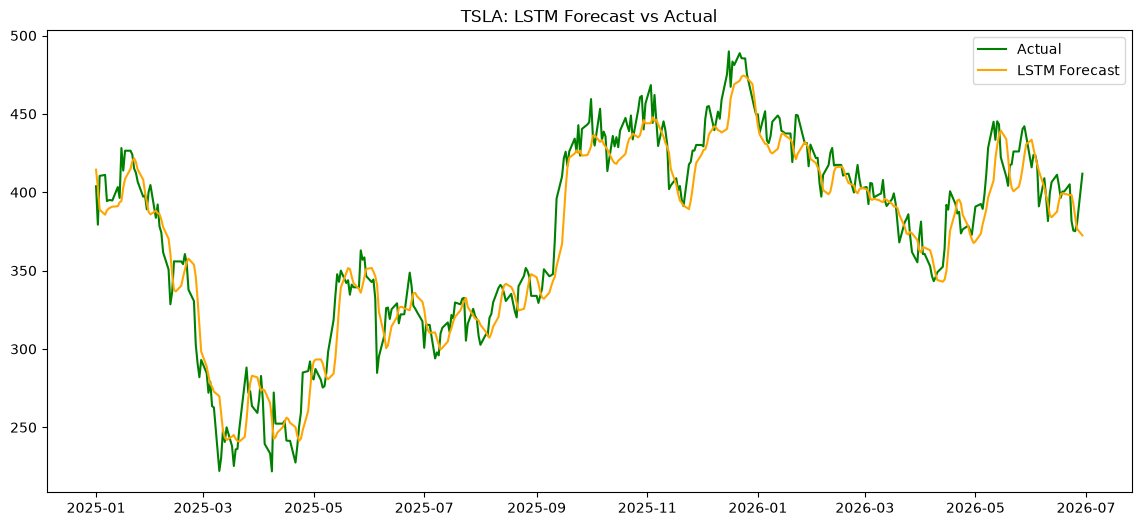

In [11]:
plt.figure(figsize=(14, 6))
plt.plot(test.index, actual, label="Actual", color="green")
plt.plot(test.index, predictions, label="LSTM Forecast", color="orange")
plt.title("TSLA: LSTM Forecast vs Actual")
plt.legend()
plt.savefig("../data/processed/lstm_forecast.png", dpi=150)
plt.show()

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

lstm_mae = mean_absolute_error(actual, predictions)
lstm_rmse = np.sqrt(mean_squared_error(actual, predictions))
lstm_mape = np.mean(np.abs((actual - predictions) / actual)) * 100

comparison = pd.DataFrame({
    "Model": ["ARIMA(0,1,0)", "LSTM"],
    "MAE": [54.15, lstm_mae],
    "RMSE": [70.20, lstm_rmse],
    "MAPE (%)": [17.11, lstm_mape],
})
print(comparison)
comparison.to_csv("../data/processed/model_comparison.csv", index=False)

          Model        MAE       RMSE   MAPE (%)
0  ARIMA(0,1,0)  54.150000  70.200000  17.110000
1          LSTM  12.465366  15.992193   3.492347
